In [18]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix,
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])
X = X.apply(pd.to_numeric)  # ensure numeric

In [ ]:


# ============================================================
# CV + GRIDSEARCHCV SETUP (Expanded Grid)
# ============================================================
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Expanded parameter grid
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

model = SVC(
    kernel='rbf',
    gamma='auto',
    probability=True,
    random_state=42
)

print("=" * 70)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid size: {len(param_grid['C']) * len(param_grid['max_iter'])} combinations")
print(f"C values     : {param_grid['C']}")
print(f"max_iter values: {param_grid['max_iter']}")
print("=" * 70)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',      # primary scoring for ranking
    refit='f1',              # refit best model on F1 score
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# Best parameters
best_params = grid_search.best_params_
best_C = best_params['C']
best_max_iter = best_params['max_iter']
best_model = grid_search.best_estimator_

print(f"\nBest Parameters:")
print(f"   C        : {best_C}")
print(f"   max_iter : {best_max_iter}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
print(f"Best Accuracy   : {grid_search.best_score_*100:.2f}%")

# Save full GridSearchCV results
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/RBF/10_10/svm_rbf_gridsearchcv_full_results.csv', index=False)

# ============================================================
# PER-PARAMETER SUMMARY (C + max_iter)
# ============================================================
print("\n" + "=" * 70)
print("EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS")
print("=" * 70)

all_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model_fold = SVC(
                kernel='rbf',
                C=c_val,
                max_iter=iter_val,
                gamma='auto',
                probability=True,
                random_state=42
            )
            model_fold.fit(X_train, y_train)

            y_pred = model_fold.predict(X_test)
            y_prob = model_fold.predict_proba(X_test)[:, 1]
            y_pred_train = model_fold.predict(X_train)

            all_results.append({
                'C': c_val,
                'max_iter': iter_val,
                'fold_number': fold_idx + 1,
                'split_repeat': (fold_idx // 10) + 1,
                'fold_within_repeat': (fold_idx % 10) + 1,
                'accuracy_test': accuracy_score(y_test, y_pred),
                'precision_test': precision_score(y_test, y_pred, zero_division=0),
                'recall_test': recall_score(y_test, y_pred, zero_division=0),
                'f1_test': f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test': roc_auc_score(y_test, y_prob),
                'mcc_test': matthews_corrcoef(y_test, y_pred),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
            })

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv('/content/drive/MyDrive/RBF/10_10/svm_rbf_all_C_maxiter_fold_results.csv', index=False)

# Summary table
summary = all_results_df.groupby(['C', 'max_iter']).agg({
    'accuracy_test': ['mean', 'std'],
    'f1_test': ['mean', 'std'],
    'roc_auc_test': ['mean', 'std'],
    'mcc_test': ['mean', 'std']
}).round(4)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.to_csv('/content/drive/MyDrive/RBF/10_10/svm_rbf_summary_by_C_maxiter.csv', index=False)

print("\nSUMMARY BY C AND max_iter (Top 10 shown):")
print(summary.sort_values('f1_test_mean', ascending=False).head(10).to_string(index=False))

print("\n" + "=" * 70)
print("Grid Search Completed Successfully!")
print("=" * 70)

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 100 (10 folds × 10 repeats)
Parameter grid size: 70 combinations
C values     : [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
max_iter values: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Fitting 100 folds for each of 70 candidates, totalling 7000 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Best Parameters:
   C        : 1
   max_iter : 100
Best CV F1 Score: 0.9957
Best Accuracy   : 99.57%

EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


SUMMARY BY C AND max_iter (Top 10 shown):
   C  max_iter  accuracy_test_mean  accuracy_test_std  f1_test_mean  f1_test_std  roc_auc_test_mean  roc_auc_test_std  mcc_test_mean  mcc_test_std
10.0       500              0.9957             0.0245         0.996       0.0228                1.0               0.0         0.9923         0.044
10.0       600              0.9957             0.0245         0.996       0.0228                1.0               0.0         0.9923         0.044
10.0       900              0.9957             0.0245         0.996       0.0228                1.0               0.0         0.9923         0.044
10.0      1000              0.9957             0.0245         0.996       0.0228                1.0               0.0         0.9923         0.044
 5.0       600              0.9957             0.0245         0.996       0.0228                1.0               0.0         0.9923         0.044
 5.0       500              0.9957             0.0245         0.996       0

In [19]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix,
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])
X = X.apply(pd.to_numeric)  # ensure numeric

# ============================================================
# CV + GRIDSEARCHCV SETUP (Expanded Grid)
# ============================================================
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Expanded parameter grid
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

model = SVC(
    kernel='rbf',
    gamma='auto',
    probability=True,
    random_state=42
)

print("=" * 70)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid size: {len(param_grid['C']) * len(param_grid['max_iter'])} combinations")
print(f"C values     : {param_grid['C']}")
print(f"max_iter values: {param_grid['max_iter']}")
print("=" * 70)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',      # primary scoring for ranking
    refit='f1',              # refit best model on F1 score
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# Best parameters
best_params = grid_search.best_params_
best_C = best_params['C']
best_max_iter = best_params['max_iter']
best_model = grid_search.best_estimator_

print(f"\nBest Parameters:")
print(f"   C        : {best_C}")
print(f"   max_iter : {best_max_iter}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
print(f"Best Accuracy   : {grid_search.best_score_*100:.2f}%")

# Save full GridSearchCV results
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/RBF/10_5/svm_rbf_gridsearchcv_full_results.csv', index=False)

# ============================================================
# PER-PARAMETER SUMMARY (C + max_iter)
# ============================================================
print("\n" + "=" * 70)
print("EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS")
print("=" * 70)

all_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model_fold = SVC(
                kernel='rbf',
                C=c_val,
                max_iter=iter_val,
                gamma='auto',
                probability=True,
                random_state=42
            )
            model_fold.fit(X_train, y_train)

            y_pred = model_fold.predict(X_test)
            y_prob = model_fold.predict_proba(X_test)[:, 1]
            y_pred_train = model_fold.predict(X_train)

            all_results.append({
                'C': c_val,
                'max_iter': iter_val,
                'fold_number': fold_idx + 1,
                'split_repeat': (fold_idx // 10) + 1,
                'fold_within_repeat': (fold_idx % 10) + 1,
                'accuracy_test': accuracy_score(y_test, y_pred),
                'precision_test': precision_score(y_test, y_pred, zero_division=0),
                'recall_test': recall_score(y_test, y_pred, zero_division=0),
                'f1_test': f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test': roc_auc_score(y_test, y_prob),
                'mcc_test': matthews_corrcoef(y_test, y_pred),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
            })

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv('/content/drive/MyDrive/RBF/10_5/svm_rbf_all_C_maxiter_fold_results.csv', index=False)

# Summary table
summary = all_results_df.groupby(['C', 'max_iter']).agg({
    'accuracy_test': ['mean', 'std'],
    'f1_test': ['mean', 'std'],
    'roc_auc_test': ['mean', 'std'],
    'mcc_test': ['mean', 'std']
}).round(4)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.to_csv('/content/drive/MyDrive/RBF/10_5/svm_rbf_summary_by_C_maxiter.csv', index=False)

print("\nSUMMARY BY C AND max_iter (Top 10 shown):")
print(summary.sort_values('f1_test_mean', ascending=False).head(10).to_string(index=False))

print("\n" + "=" * 70)
print("Grid Search Completed Successfully!")
print("=" * 70)



# Save best model as pickle
with open('/content/drive/MyDrive/RBF/10_5/svm_rbf_best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Best model saved to svm_rbf_best_model.pkl")

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 50 (10 folds × 10 repeats)
Parameter grid size: 70 combinations
C values     : [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
max_iter values: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Fitting 50 folds for each of 70 candidates, totalling 3500 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Best Parameters:
   C        : 1
   max_iter : 100
Best CV F1 Score: 0.9971
Best Accuracy   : 99.71%

EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


SUMMARY BY C AND max_iter (Top 10 shown):
   C  max_iter  accuracy_test_mean  accuracy_test_std  f1_test_mean  f1_test_std  roc_auc_test_mean  roc_auc_test_std  mcc_test_mean  mcc_test_std
10.0       500              0.9971             0.0202        0.9971       0.0202                1.0               0.0          0.995        0.0354
10.0       600              0.9971             0.0202        0.9971       0.0202                1.0               0.0          0.995        0.0354
10.0       900              0.9971             0.0202        0.9971       0.0202                1.0               0.0          0.995        0.0354
10.0      1000              0.9971             0.0202        0.9971       0.0202                1.0               0.0          0.995        0.0354
 5.0       600              0.9971             0.0202        0.9971       0.0202                1.0               0.0          0.995        0.0354
 5.0       500              0.9971             0.0202        0.9971       0

In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix,
)

# ============================================================


# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])
X = X.apply(pd.to_numeric)  # ensure numeric

# ============================================================
# CV + GRIDSEARCHCV SETUP (Expanded Grid)
# ============================================================
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Expanded parameter grid
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

model = SVC(
    kernel='rbf',
    gamma='auto',
    probability=True,
    random_state=42
)

print("=" * 70)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid size: {len(param_grid['C']) * len(param_grid['max_iter'])} combinations")
print(f"C values     : {param_grid['C']}")
print(f"max_iter values: {param_grid['max_iter']}")
print("=" * 70)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',      # primary scoring for ranking
    refit='f1',              # refit best model on F1 score
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# Best parameters
best_params = grid_search.best_params_
best_C = best_params['C']
best_max_iter = best_params['max_iter']
best_model = grid_search.best_estimator_

print(f"\nBest Parameters:")
print(f"   C        : {best_C}")
print(f"   max_iter : {best_max_iter}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
print(f"Best Accuracy   : {grid_search.best_score_*100:.2f}%")

# Save full GridSearchCV results
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/RBF/10_3/svm_rbf_gridsearchcv_full_results.csv', index=False)

# ============================================================
# PER-PARAMETER SUMMARY (C + max_iter)
# ============================================================
print("\n" + "=" * 70)
print("EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS")
print("=" * 70)

all_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model_fold = SVC(
                kernel='rbf',
                C=c_val,
                max_iter=iter_val,
                gamma='auto',
                probability=True,
                random_state=42
            )
            model_fold.fit(X_train, y_train)

            y_pred = model_fold.predict(X_test)
            y_prob = model_fold.predict_proba(X_test)[:, 1]
            y_pred_train = model_fold.predict(X_train)

            all_results.append({
                'C': c_val,
                'max_iter': iter_val,
                'fold_number': fold_idx + 1,
                'split_repeat': (fold_idx // 10) + 1,
                'fold_within_repeat': (fold_idx % 10) + 1,
                'accuracy_test': accuracy_score(y_test, y_pred),
                'precision_test': precision_score(y_test, y_pred, zero_division=0),
                'recall_test': recall_score(y_test, y_pred, zero_division=0),
                'f1_test': f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test': roc_auc_score(y_test, y_prob),
                'mcc_test': matthews_corrcoef(y_test, y_pred),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
            })

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv('/content/drive/MyDrive/RBF/10_3/svm_rbf_all_C_maxiter_fold_results.csv', index=False)

# Summary table
summary = all_results_df.groupby(['C', 'max_iter']).agg({
    'accuracy_test': ['mean', 'std'],
    'f1_test': ['mean', 'std'],
    'roc_auc_test': ['mean', 'std'],
    'mcc_test': ['mean', 'std']
}).round(4)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.to_csv('/content/drive/MyDrive/RBF/10_3/svm_rbf_summary_by_C_maxiter.csv', index=False)

print("\nSUMMARY BY C AND max_iter (Top 10 shown):")
print(summary.sort_values('f1_test_mean', ascending=False).head(10).to_string(index=False))

print("\n" + "=" * 70)
print("Grid Search Completed Successfully!")
print("=" * 70)

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 30 (10 folds × 10 repeats)
Parameter grid size: 70 combinations
C values     : [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
max_iter values: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Fitting 30 folds for each of 70 candidates, totalling 2100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Best Parameters:
   C        : 1
   max_iter : 100
Best CV F1 Score: 0.9952
Best Accuracy   : 99.52%

EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


SUMMARY BY C AND max_iter (Top 10 shown):
   C  max_iter  accuracy_test_mean  accuracy_test_std  f1_test_mean  f1_test_std  roc_auc_test_mean  roc_auc_test_std  mcc_test_mean  mcc_test_std
10.0       500              0.9952             0.0261        0.9952       0.0261                1.0               0.0         0.9917        0.0456
10.0       600              0.9952             0.0261        0.9952       0.0261                1.0               0.0         0.9917        0.0456
10.0       900              0.9952             0.0261        0.9952       0.0261                1.0               0.0         0.9917        0.0456
10.0      1000              0.9952             0.0261        0.9952       0.0261                1.0               0.0         0.9917        0.0456
 5.0       600              0.9952             0.0261        0.9952       0.0261                1.0               0.0         0.9917        0.0456
 5.0       500              0.9952             0.0261        0.9952       0

In [ ]:
#final

In [2]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix,
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])
X = X.apply(pd.to_numeric)  # ensure numeric

# ============================================================
# CV + GRIDSEARCHCV SETUP (Expanded Grid)
# ============================================================
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=2, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Expanded parameter grid
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

model = SVC(
    kernel='rbf',
    gamma='auto',
    probability=True,
    random_state=42
)

print("=" * 70)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid size: {len(param_grid['C']) * len(param_grid['max_iter'])} combinations")
print(f"C values     : {param_grid['C']}")
print(f"max_iter values: {param_grid['max_iter']}")
print("=" * 70)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',      # primary scoring for ranking
    refit='f1',              # refit best model on F1 score
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# Best parameters
best_params = grid_search.best_params_
best_C = best_params['C']
best_max_iter = best_params['max_iter']
best_model = grid_search.best_estimator_

print(f"\nBest Parameters:")
print(f"   C        : {best_C}")
print(f"   max_iter : {best_max_iter}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
print(f"Best Accuracy   : {grid_search.best_score_*100:.2f}%")

# Save full GridSearchCV results
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/RBF/10_2/svm_rbf_gridsearchcv_full_results.csv', index=False)

# ============================================================
# PER-PARAMETER SUMMARY (C + max_iter)
# ============================================================
print("\n" + "=" * 70)
print("EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS")
print("=" * 70)

all_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model_fold = SVC(
                kernel='rbf',
                C=c_val,
                max_iter=iter_val,
                gamma='auto',
                probability=True,
                random_state=42
            )
            model_fold.fit(X_train, y_train)

            y_pred = model_fold.predict(X_test)
            y_prob = model_fold.predict_proba(X_test)[:, 1]
            y_pred_train = model_fold.predict(X_train)

            all_results.append({
                'C': c_val,
                'max_iter': iter_val,
                'fold_number': fold_idx + 1,
                'split_repeat': (fold_idx // 10) + 1,
                'fold_within_repeat': (fold_idx % 10) + 1,
                'accuracy_test': accuracy_score(y_test, y_pred),
                'precision_test': precision_score(y_test, y_pred, zero_division=0),
                'recall_test': recall_score(y_test, y_pred, zero_division=0),
                'f1_test': f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test': roc_auc_score(y_test, y_prob),
                'mcc_test': matthews_corrcoef(y_test, y_pred),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
            })

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv('/content/drive/MyDrive/RBF/10_2/svm_rbf_all_C_maxiter_fold_results.csv', index=False)

# Summary table
summary = all_results_df.groupby(['C', 'max_iter']).agg({
    'accuracy_test': ['mean', 'std'],
    'f1_test': ['mean', 'std'],
    'roc_auc_test': ['mean', 'std'],
    'mcc_test': ['mean', 'std'],
        'precision_test': ['mean', 'std'],   # ← added
    'recall_test': ['mean', 'std'],      # ← added

}).round(4)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.to_csv('/content/drive/MyDrive/RBF/10_2/svm_rbf_summary_by_C_maxiter.csv', index=False)

print("\nSUMMARY BY C AND max_iter (Top 10 shown):")
print(summary.sort_values('f1_test_mean', ascending=False).head(10).to_string(index=False))

print("\n" + "=" * 70)
print("Grid Search Completed Successfully!")
print("=" * 70)



best_model = grid_search.best_estimator_
# ============================================================
# SAVE SPECIFIC MODEL (C=10, max_iter=500)
# ============================================================



# Save model
with open('/content/drive/MyDrive/RBF/10_2/svm_rbf_C10_iter500.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("\nModel saved successfully!")
print("Filename: svm_rbf_C10_iter500.pkl")


Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 20 (10 folds × 10 repeats)
Parameter grid size: 70 combinations
C values     : [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
max_iter values: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Fitting 20 folds for each of 70 candidates, totalling 1400 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Best Parameters:
   C        : 1
   max_iter : 100
Best CV F1 Score: 0.9929
Best Accuracy   : 99.29%

EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


SUMMARY BY C AND max_iter (Top 10 shown):
   C  max_iter  accuracy_test_mean  accuracy_test_std  f1_test_mean  f1_test_std  roc_auc_test_mean  roc_auc_test_std  mcc_test_mean  mcc_test_std  precision_test_mean  precision_test_std  recall_test_mean  recall_test_std
10.0       500              0.9929             0.0319        0.9929       0.0319                1.0               0.0         0.9875        0.0559               0.9875              0.0559               1.0              0.0
10.0       600              0.9929             0.0319        0.9929       0.0319                1.0               0.0         0.9875        0.0559               0.9875              0.0559               1.0              0.0
10.0       900              0.9929             0.0319        0.9929       0.0319                1.0               0.0         0.9875        0.0559               0.9875              0.0559               1.0              0.0
10.0      1000              0.9929             0.0319        0.99

In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix,
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])
X = X.apply(pd.to_numeric)  # ensure numeric

# ============================================================
# CV + GRIDSEARCHCV SETUP (Expanded Grid)
# ============================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Expanded parameter grid
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

model = SVC(
    kernel='rbf',
    gamma='auto',
    probability=True,
    random_state=42
)

print("=" * 70)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid size: {len(param_grid['C']) * len(param_grid['max_iter'])} combinations")
print(f"C values     : {param_grid['C']}")
print(f"max_iter values: {param_grid['max_iter']}")
print("=" * 70)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',      # primary scoring for ranking
    refit='f1',              # refit best model on F1 score
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# Best parameters
best_params = grid_search.best_params_
best_C = best_params['C']
best_max_iter = best_params['max_iter']
best_model = grid_search.best_estimator_

print(f"\nBest Parameters:")
print(f"   C        : {best_C}")
print(f"   max_iter : {best_max_iter}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
print(f"Best Accuracy   : {grid_search.best_score_*100:.2f}%")

# Save full GridSearchCV results
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/RBF/only10/svm_rbf_gridsearchcv_full_results.csv', index=False)

# ============================================================
# PER-PARAMETER SUMMARY (C + max_iter)
# ============================================================
print("\n" + "=" * 70)
print("EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS")
print("=" * 70)

all_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model_fold = SVC(
                kernel='rbf',
                C=c_val,
                max_iter=iter_val,
                gamma='auto',
                probability=True,
                random_state=42
            )
            model_fold.fit(X_train, y_train)

            y_pred = model_fold.predict(X_test)
            y_prob = model_fold.predict_proba(X_test)[:, 1]
            y_pred_train = model_fold.predict(X_train)

            all_results.append({
                'C': c_val,
                'max_iter': iter_val,
                'fold_number': fold_idx + 1,
                'split_repeat': (fold_idx // 10) + 1,
                'fold_within_repeat': (fold_idx % 10) + 1,
                'accuracy_test': accuracy_score(y_test, y_pred),
                'precision_test': precision_score(y_test, y_pred, zero_division=0),
                'recall_test': recall_score(y_test, y_pred, zero_division=0),
                'f1_test': f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test': roc_auc_score(y_test, y_prob),
                'mcc_test': matthews_corrcoef(y_test, y_pred),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
            })

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv('/content/drive/MyDrive/RBF/only10/svm_rbf_all_C_maxiter_fold_results.csv', index=False)

# Summary table
summary = all_results_df.groupby(['C', 'max_iter']).agg({
    'accuracy_test': ['mean', 'std'],
    'f1_test': ['mean', 'std'],
    'roc_auc_test': ['mean', 'std'],
    'mcc_test': ['mean', 'std']
}).round(4)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.to_csv('/content/drive/MyDrive/RBF/only10/svm_rbf_summary_by_C_maxiter.csv', index=False)

print("\nSUMMARY BY C AND max_iter (Top 10 shown):")
print(summary.sort_values('f1_test_mean', ascending=False).head(10).to_string(index=False))

print("\n" + "=" * 70)
print("Grid Search Completed Successfully!")
print("=" * 70)

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 10 (10 folds × 10 repeats)
Parameter grid size: 70 combinations
C values     : [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
max_iter values: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Fitting 10 folds for each of 70 candidates, totalling 700 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Best Parameters:
   C        : 1
   max_iter : 100
Best CV F1 Score: 0.9857
Best Accuracy   : 98.57%

EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-


SUMMARY BY C AND max_iter (Top 10 shown):
   C  max_iter  accuracy_test_mean  accuracy_test_std  f1_test_mean  f1_test_std  roc_auc_test_mean  roc_auc_test_std  mcc_test_mean  mcc_test_std
10.0       500              0.9857             0.0452        0.9857       0.0452                1.0               0.0          0.975        0.0791
10.0       600              0.9857             0.0452        0.9857       0.0452                1.0               0.0          0.975        0.0791
10.0       900              0.9857             0.0452        0.9857       0.0452                1.0               0.0          0.975        0.0791
10.0      1000              0.9857             0.0452        0.9857       0.0452                1.0               0.0          0.975        0.0791
 5.0       600              0.9857             0.0452        0.9857       0.0452                1.0               0.0          0.975        0.0791
 5.0       500              0.9857             0.0452        0.9857       0

In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix,
)

# ============================================================
# DATA LOADING
# ============================================================
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data = data.T

y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")

data.reset_index(inplace=True)
data.drop("index", axis=1, inplace=True)

X = data
X.columns = X.iloc[0]
X = X.drop(X.index[0])
X = X.apply(pd.to_numeric)  # ensure numeric

# ============================================================
# CV + GRIDSEARCHCV SETUP (Expanded Grid)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(matthews_corrcoef),
}

# Expanded parameter grid
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
    'max_iter': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

model = SVC(
    kernel='rbf',
    gamma='auto',
    probability=True,
    random_state=42
)

print("=" * 70)
print("Starting GridSearchCV with RepeatedStratifiedKFold")
print(f"Total CV splits: {cv.get_n_splits(X, y)} (10 folds × 10 repeats)")
print(f"Parameter grid size: {len(param_grid['C']) * len(param_grid['max_iter'])} combinations")
print(f"C values     : {param_grid['C']}")
print(f"max_iter values: {param_grid['max_iter']}")
print("=" * 70)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',      # primary scoring for ranking
    refit='f1',              # refit best model on F1 score
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# Best parameters
best_params = grid_search.best_params_
best_C = best_params['C']
best_max_iter = best_params['max_iter']
best_model = grid_search.best_estimator_

print(f"\nBest Parameters:")
print(f"   C        : {best_C}")
print(f"   max_iter : {best_max_iter}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
print(f"Best Accuracy   : {grid_search.best_score_*100:.2f}%")

# Save full GridSearchCV results
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df.to_csv('/content/drive/MyDrive/RBF/only5/svm_rbf_gridsearchcv_full_results.csv', index=False)

# ============================================================
# PER-PARAMETER SUMMARY (C + max_iter)
# ============================================================
print("\n" + "=" * 70)
print("EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS")
print("=" * 70)

all_results = []

for c_val in param_grid['C']:
    for iter_val in param_grid['max_iter']:
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model_fold = SVC(
                kernel='rbf',
                C=c_val,
                max_iter=iter_val,
                gamma='auto',
                probability=True,
                random_state=42
            )
            model_fold.fit(X_train, y_train)

            y_pred = model_fold.predict(X_test)
            y_prob = model_fold.predict_proba(X_test)[:, 1]
            y_pred_train = model_fold.predict(X_train)

            all_results.append({
                'C': c_val,
                'max_iter': iter_val,
                'fold_number': fold_idx + 1,
                'split_repeat': (fold_idx // 10) + 1,
                'fold_within_repeat': (fold_idx % 10) + 1,
                'accuracy_test': accuracy_score(y_test, y_pred),
                'precision_test': precision_score(y_test, y_pred, zero_division=0),
                'recall_test': recall_score(y_test, y_pred, zero_division=0),
                'f1_test': f1_score(y_test, y_pred, zero_division=0),
                'roc_auc_test': roc_auc_score(y_test, y_prob),
                'mcc_test': matthews_corrcoef(y_test, y_pred),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
            })

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv('/content/drive/MyDrive/RBF/only5/svm_rbf_all_C_maxiter_fold_results.csv', index=False)

# Summary table
summary = all_results_df.groupby(['C', 'max_iter']).agg({
    'accuracy_test': ['mean', 'std'],
    'f1_test': ['mean', 'std'],
    'roc_auc_test': ['mean', 'std'],
        'precision_test': ['mean', 'std'],   # ← added
    'recall_test': ['mean', 'std'],      # ← added

    'mcc_test': ['mean', 'std']
}).round(4)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary.to_csv('/content/drive/MyDrive/RBF/only5/svm_rbf_summary_by_C_maxiter.csv', index=False)

print("\nSUMMARY BY C AND max_iter (Top 10 shown):")
print(summary.sort_values('f1_test_mean', ascending=False).head(10).to_string(index=False))

print("\n" + "=" * 70)
print("Grid Search Completed Successfully!")
print("=" * 70)

Starting GridSearchCV with RepeatedStratifiedKFold
Total CV splits: 5 (10 folds × 10 repeats)
Parameter grid size: 70 combinations
C values     : [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
max_iter values: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Fitting 5 folds for each of 70 candidates, totalling 350 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Best Parameters:
   C        : 1
   max_iter : 100
Best CV F1 Score: 0.9867
Best Accuracy   : 98.67%

EXTRACTING RESULTS FOR ALL C AND max_iter COMBINATIONS

SUMMARY BY C AND max_iter (Top 10 shown):
   C  max_iter  accuracy_test_mean  accuracy_test_std  f1_test_mean  f1_test_std  roc_auc_test_mean  roc_auc_test_std  mcc_test_mean  mcc_test_std
10.0       500              0.9867             0.0298        0.9882       0.0263                1.0               0.0         0.9746        0.0569
10.0       600              0.9867             0.0298        0.9882       0.0263                1.0               0.0         0.9746        0.0569
10.0       900              0.9867             0.0298        0.9882       0.0263                1.0               0.0         0.9746        0.0569
10.0      1000              0.9867             0.0298        0.9882       0.0263                1.0               0.0         0.9746        0.0569
 5.0       600              0.9867             0.0298        0.9

we chose 99.71 again


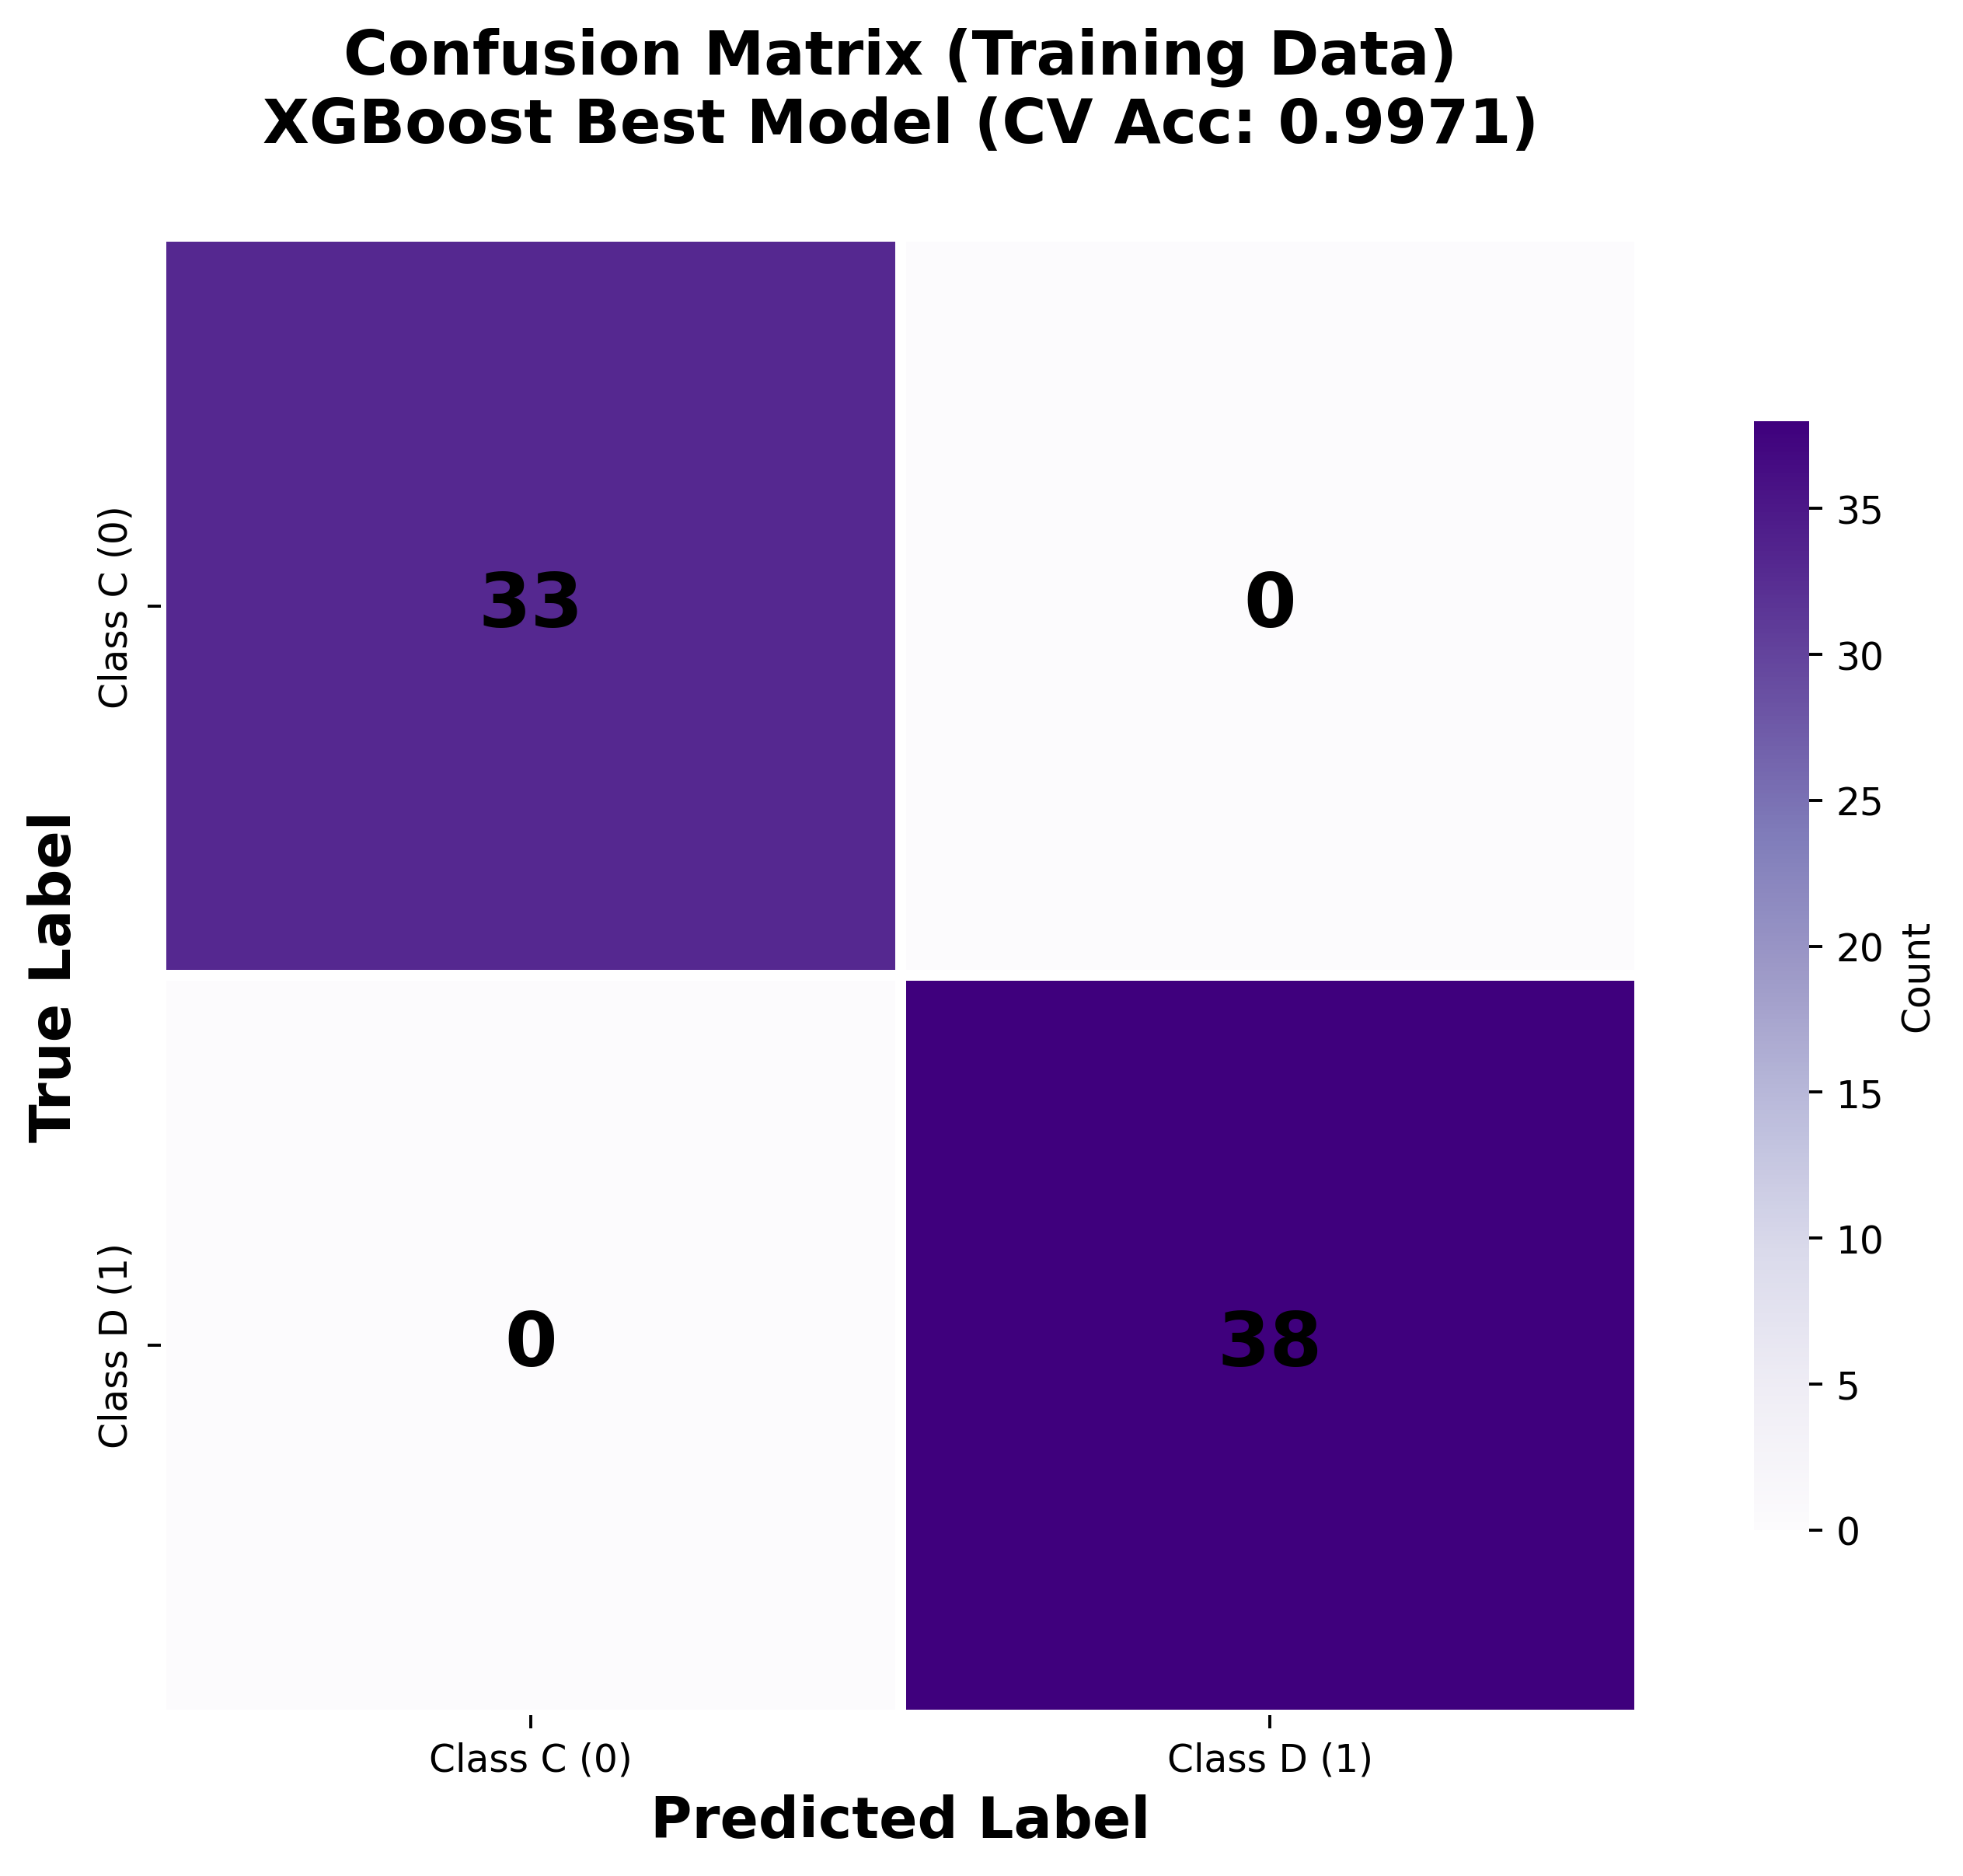

✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_20260624_164940.png'

FINAL MODEL PERFORMANCE ON TRAINING DATA
Best CV Accuracy : 0.9971
Training Accuracy: 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1-Score         : 1.0000
MCC              : 1.0000

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                33             0
True Class D                 0            38


In [21]:


# ======================================================================
#  PINK CONFUSION MATRIX - BEST CV MODEL
# ======================================================================

y_pred = best_model.predict(X)
cm = confusion_matrix(y, y_pred)

plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nXGBoost Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.savefig(f'confusion_matrix_best_xgboost_{plot_timestamp}.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_{plot_timestamp}.png'")

# Metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE ON TRAINING DATA")
print("="*70)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\n" + "="*70)
print("CONFUSION MATRIX (Raw Counts)")
print("="*70)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")


Calculating SHAP values (this may take a moment)...


  0%|          | 0/71 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

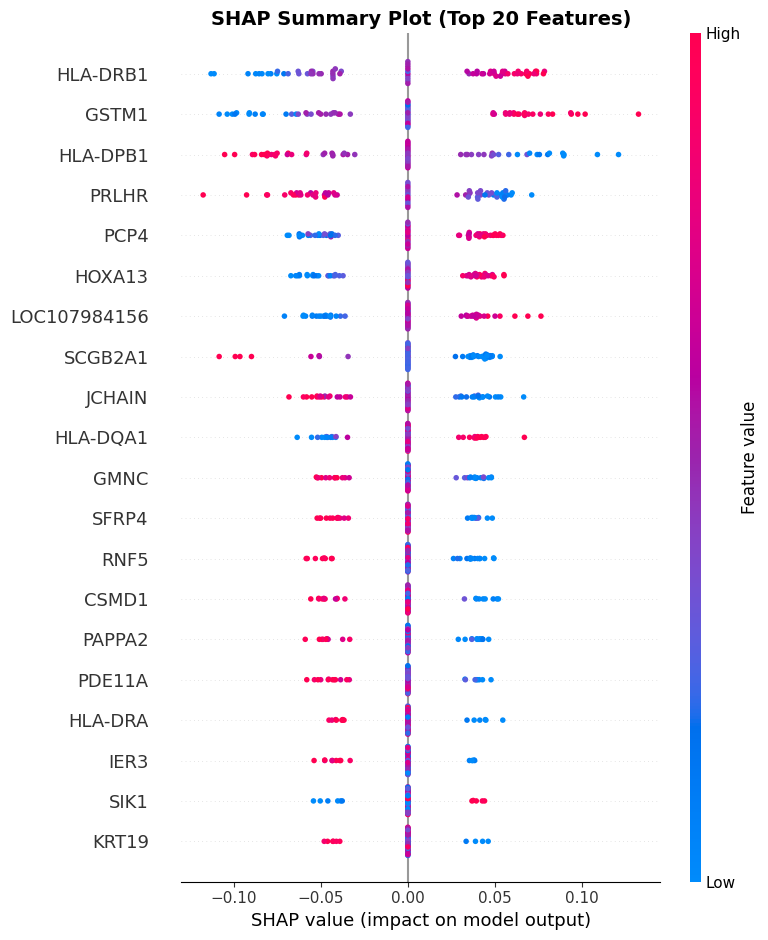

✅ SHAP summary plot saved as 'shap_summary_20260624_1643.png'


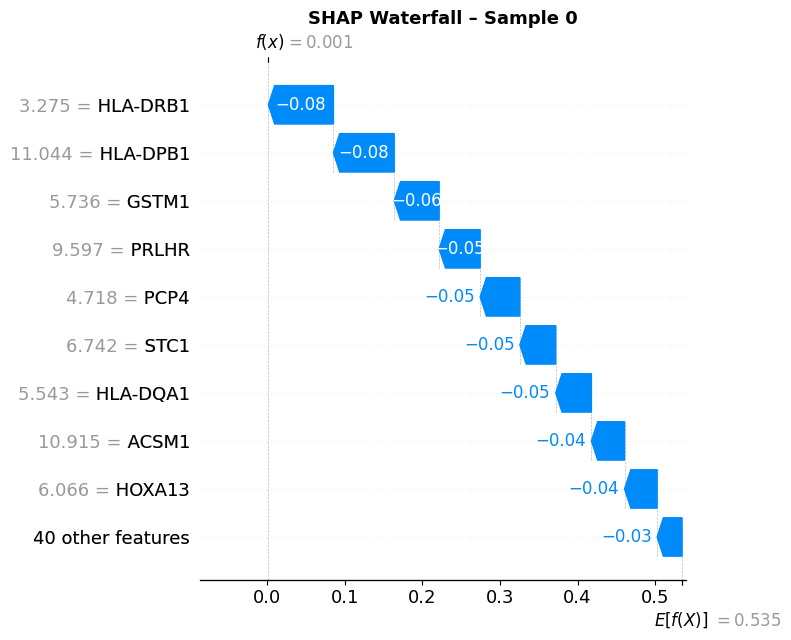

✅ SHAP waterfall saved as 'shap_waterfall_20260624_1643.png'
✅ SHAP importance saved as 'shap_importance_20260624_1643.csv'

Top 10 SHAP Features:
     Feature  Mean_Abs_SHAP
    HLA-DRB1       0.052325
       GSTM1       0.049351
    HLA-DPB1       0.046093
       PRLHR       0.043875
        PCP4       0.034651
      HOXA13       0.030716
LOC107984156       0.026982
     SCGB2A1       0.025253
      JCHAIN       0.023903
    HLA-DQA1       0.018499


In [25]:

import shap
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SHAP ANALYSIS FOR SVM
# ============================================================

print("\nCalculating SHAP values (this may take a moment)...")

# Convert dataframe to numpy
X_array = X.values

# Small background sample for faster computation
background = shap.sample(X_array, 100, random_state=42)

# Feature names
feature_names = list(X.columns)

shap_values = explainer.shap_values(X_array)

# Extract correct class (class 1 for binary classification)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]       # list output: take class 1
elif shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1] # 3D array: take class 1 slice
else:
    shap_vals = shap_values          # already 2D, use as-is

# ============================================================
# KERNEL EXPLAINER
# ============================================================

explainer = shap.KernelExplainer(
    best_model.predict_proba,
    background
)

# Compute SHAP values
shap_values = explainer.shap_values(X_array)

# --- 9a. SHAP Summary Plot (Beeswarm) ---
plt.figure()


shap.summary_plot(
    shap_vals,
    features=X_array,
    feature_names=feature_names,
    max_display=20,
    plot_type="dot",
    show=False
)

plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ SHAP summary plot saved as 'shap_summary_{timestamp}.png'")















# --- 9c. SHAP Waterfall (first sample) ---
# --- 9c. SHAP Waterfall (first sample) ---

base_val = explainer.expected_value

if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

shap_exp = shap.Explanation(
    values        = shap_vals[0],
    base_values   = base_val,
    data          = X_array[0],
    feature_names = feature_names
)

plt.figure()

shap.waterfall_plot(
    shap_exp,
    show=False
)

plt.title(
    'SHAP Waterfall – Sample 0',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    f'shap_waterfall_{timestamp}.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f"✅ SHAP waterfall saved as 'shap_waterfall_{timestamp}.png'")

# --- 9d. SHAP Feature Importance CSV ---

mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(shap_vals).mean(axis=0)
}).sort_values(
    'Mean_Abs_SHAP',
    ascending=False
).reset_index(drop=True)

mean_shap_df.to_csv(
    f'shap_importance_{timestamp}.csv',
    index=False
)

print(f"✅ SHAP importance saved as 'shap_importance_{timestamp}.csv'")

print("\nTop 10 SHAP Features:")

print(mean_shap_df.head(10).to_string(index=False))

In [26]:
import pandas as pd

In [27]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [28]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [29]:
data = merged.T

In [30]:

import pandas as pd



# Labels from row index
y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.values.astype(int)

# Feature matrix
data = data.reset_index(drop=True)
data.columns = data.iloc[0]
data = data.drop(data.index[0]).apply(pd.to_numeric)
X = data
y_val = y
X_val = X

import pickle
import joblib
#best_model = joblib.load('/content/drive/MyDrive/RBF/10_5/svm_rbf_best_model.pkl')

# Open the file in read-binary mode



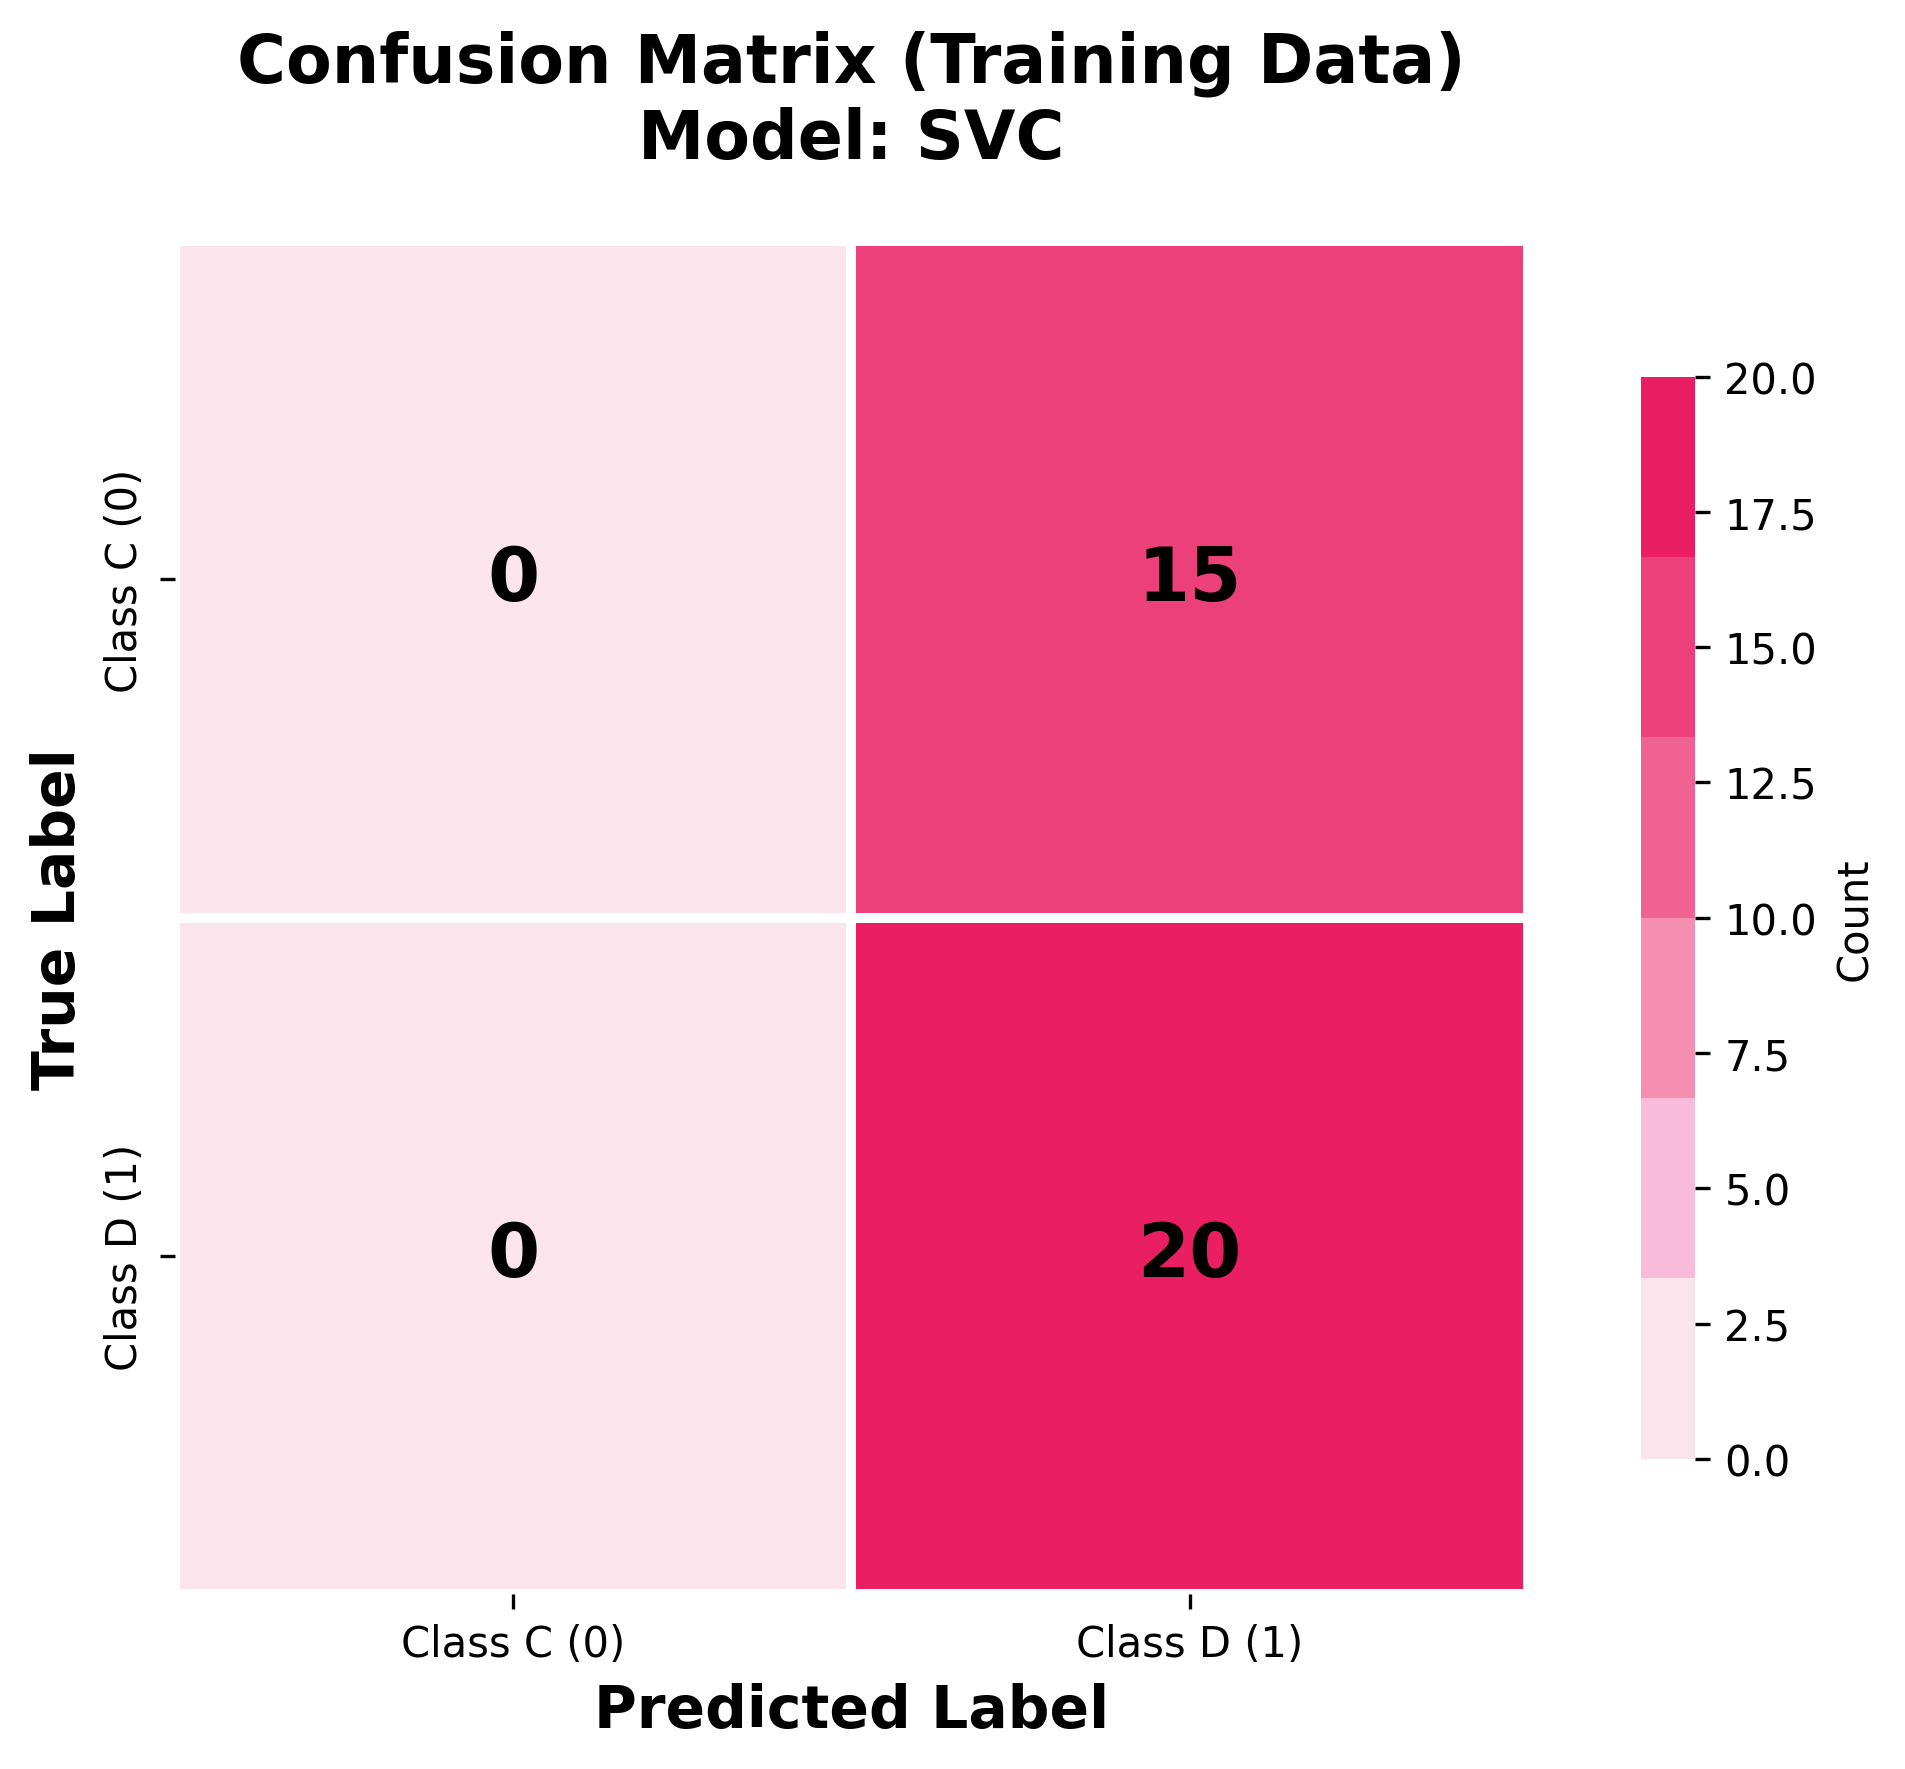


✅ Confusion matrix saved as 'confusion_matrix_20260624_165528.png'

MODEL PERFORMANCE METRICS
Accuracy:  0.5714
Precision: 0.5714
Recall:    1.0000
F1-Score:  0.7273
MCC:       0.0000

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                 0            15
True Class D                 0            20


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap

# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = best_model.predict(X_val)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred)

# ============================================================
# PLOT PINK CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pink colormap
pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

# Title with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nModel: {type(best_model).__name__}',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    f'confusion_matrix_{timestamp}.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print(f"\n✅ Confusion matrix saved as 'confusion_matrix_{timestamp}.png'")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [32]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime


# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.5714
ROC-AUC              : 0.5000
AUCPRC               : 0.5714
Avg Precision        : 0.5714
F1 Score             : 0.7273
F1 Macro             : 0.3636
F1 Weighted          : 0.4156
Precision            : 0.5714
Recall               : 1.0000
MCC                  : 0.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        15
           1     0.5714    1.0000    0.7273        20

    accuracy                         0.5714        35
   macro avg     0.2857    0.5000    0.3636        35
weighted avg     0.3265    0.5714    0.4156        35


✅ Metrics saved as 'validation_metrics_20260624_1655.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/loc

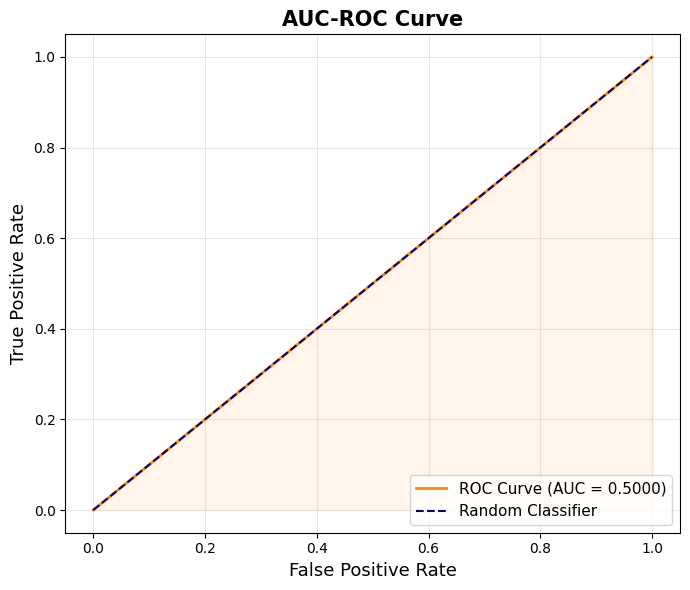

✅ AUC-ROC curve saved as 'aucroc_curve.png'


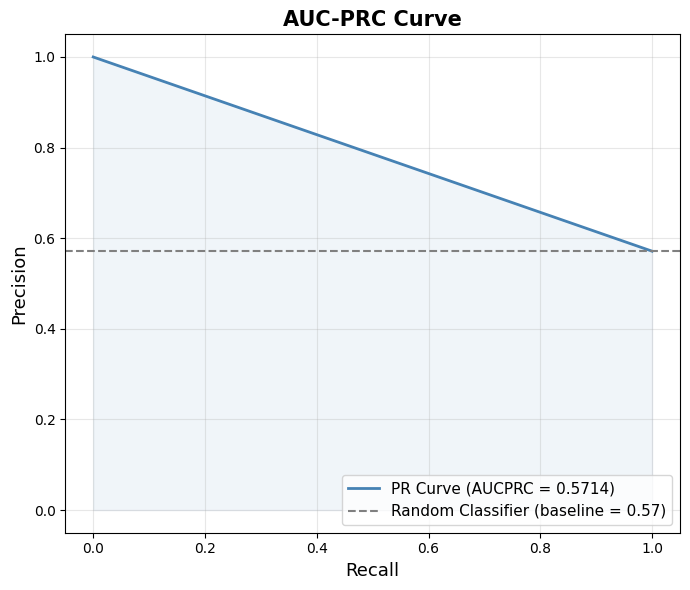

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [33]:
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")

